# Instalación adicional con pip
```bash
pip install pdfplumber wordcloud
```

In [2]:
# =========================================================
# IMPORTACIÓN DE LIBRERÍAS
# =========================================================

import os
import re
import unicodedata

import nltk
import chardet
import pdfplumber

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from langdetect import detect

from wordcloud import WordCloud

from nltk.corpus import stopwords

from nltk.tokenize import (
    word_tokenize,
    sent_tokenize
)

from nltk.stem import (
    SnowballStemmer,
    WordNetLemmatizer
)

from sklearn.feature_extraction.text import (
    CountVectorizer
)

In [3]:
# =========================================================
# DESCARGA DE RECURSOS NLTK
# =========================================================

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /home/rusok/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/rusok/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/rusok/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/rusok/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [4]:
# =========================================================
# CONFIGURACIÓN GENERAL
# =========================================================

ARCHIVO_PDF = (
    "prueba.pdf"
)

MAX_CARACTERES = 3000

In [5]:
# =========================================================
# FUNCIONES AUXILIARES
# =========================================================

def mostrar_titulo(texto):

    """
    Mostrar títulos decorativos.
    """

    print("\n")
    print("┌" + "─" * 70 + "┐")
    print(f"│ {texto:<68} │")
    print("└" + "─" * 70 + "┘")

In [6]:
# =========================================================

def normalizar_texto(texto):

    """
    Normalización textual:
    - minúsculas
    - eliminación de acentos
    - espacios redundantes
    """

    texto = texto.lower()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(

        c

        for c in texto

        if not unicodedata.combining(c)

    )

    texto = re.sub(
        r"\s+",
        " ",
        texto
    ).strip()

    return texto

In [7]:
# =========================================================

def generar_nube_palabras(texto):

    """
    Generación de nube de palabras.
    """

    wordcloud = WordCloud(

        width=1400,
        height=700,
        background_color="white",
        colormap="viridis",
        max_words=100

    ).generate(texto)

    plt.figure(figsize=(16, 8))

    plt.imshow(
        wordcloud,
        interpolation="bilinear"
    )

    plt.axis("off")

    plt.title(
        "NUBE DE PALABRAS - MINERÍA DE TEXTOS",
        fontsize=20
    )

    plt.show()

In [8]:
# =========================================================
# ETAPA 0 - PREPARACIÓN DE FUENTES
# =========================================================

mostrar_titulo(
    "ETAPA 0 - PREPARACIÓN DE FUENTES"
)



┌──────────────────────────────────────────────────────────────────────┐
│ ETAPA 0 - PREPARACIÓN DE FUENTES                                     │
└──────────────────────────────────────────────────────────────────────┘


In [9]:
# =========================================================
# VERIFICACIÓN DE EXISTENCIA DEL PDF
# =========================================================

if not os.path.exists(ARCHIVO_PDF):

    raise FileNotFoundError(
        f"No se encontró el archivo: {ARCHIVO_PDF}"
    )

In [10]:
# =========================================================
# CONTROL DE TAMAÑO DEL ARCHIVO
# =========================================================

tamaño_bytes = os.path.getsize(
    ARCHIVO_PDF
)

tamaño_mb = tamaño_bytes / (1024 * 1024)

In [11]:
# =========================================================
# ETAPA 1 - ADQUISICIÓN DE FUENTES
# =========================================================

mostrar_titulo(
    "ETAPA 1 - ADQUISICIÓN DE FUENTES"
)



┌──────────────────────────────────────────────────────────────────────┐
│ ETAPA 1 - ADQUISICIÓN DE FUENTES                                     │
└──────────────────────────────────────────────────────────────────────┘


In [13]:
# =========================================================
# EXTRACCIÓN DE TEXTO DESDE PDF
# =========================================================

texto_original = ""

with pdfplumber.open(ARCHIVO_PDF) as pdf:

    for pagina in pdf.pages:

        contenido = pagina.extract_text()

        if contenido:

            texto_original += contenido + " "

In [14]:
# =========================================================
# VERIFICACIÓN DE CODIFICACIÓN
# =========================================================

codificacion = chardet.detect(
    texto_original.encode()
)["encoding"]

In [15]:
# =========================================================
# DETECCIÓN DE IDIOMA
# =========================================================

idioma_detectado = detect(
    texto_original
)

In [16]:
# =========================================================
# ETAPA 2 - LIMPIEZA DEL TEXTO
# =========================================================

mostrar_titulo(
    "ETAPA 2 - LIMPIEZA DEL TEXTO"
)




┌──────────────────────────────────────────────────────────────────────┐
│ ETAPA 2 - LIMPIEZA DEL TEXTO                                         │
└──────────────────────────────────────────────────────────────────────┘


In [17]:
# =========================================================
# LIMPIEZA BÁSICA
# =========================================================

texto_limpio = re.sub(
    r"\n",
    " ",
    texto_original
)

texto_limpio = re.sub(
    r"[^a-zA-Z0-9áéíóúñüÁÉÍÓÚÑÜ\s]",
    " ",
    texto_limpio
)

texto_limpio = re.sub(
    r"\s+",
    " ",
    texto_limpio
).strip()

In [18]:
# =========================================================
# ELIMINACIÓN DE RUIDO
# =========================================================

texto_limpio = re.sub(
    r"https?:\/\/\S+",
    "",
    texto_limpio
)

texto_limpio = re.sub(
    r"\d+",
    " ",
    texto_limpio
)

texto_limpio = re.sub(
    r"\s+",
    " ",
    texto_limpio
).strip()

In [19]:
# =========================================================
# NORMALIZACIÓN
# =========================================================

texto_normalizado = normalizar_texto(
    texto_limpio
)

In [20]:
# =========================================================
# TOKENIZACIÓN
# =========================================================

tokens_palabras = word_tokenize(
    texto_normalizado
)

tokens_oraciones = sent_tokenize(
    texto_normalizado
)

In [21]:
# =========================================================
# ELIMINACIÓN DE STOPWORDS
# =========================================================

stopwords_es = set(
    stopwords.words("spanish")
)

tokens_sin_stopwords = [

    palabra

    for palabra in tokens_palabras

    if palabra not in stopwords_es

]

In [22]:
# =========================================================
# DOCUMENTO FINAL PROCESADO
# =========================================================

documento_final = " ".join(
    tokens_sin_stopwords
)

In [23]:
# =========================================================
# ETAPA 3 - PREPARACIÓN PARA EL ANÁLISIS
# =========================================================

mostrar_titulo(
    "ETAPA 3 - PREPARACIÓN PARA EL ANÁLISIS"
)



┌──────────────────────────────────────────────────────────────────────┐
│ ETAPA 3 - PREPARACIÓN PARA EL ANÁLISIS                               │
└──────────────────────────────────────────────────────────────────────┘


In [24]:
# =========================================================
# STEMMING
# =========================================================

stemmer = SnowballStemmer(
    "spanish"
)

stems = [

    stemmer.stem(palabra)

    for palabra in tokens_sin_stopwords

]

In [25]:
# =========================================================
# LEMATIZACIÓN
# =========================================================

lemmatizer = WordNetLemmatizer()

lemmas = [

    lemmatizer.lemmatize(palabra)

    for palabra in tokens_sin_stopwords

]

In [26]:
# =========================================================
# MATRIZ DTM
# =========================================================

corpus = [documento_final]

vectorizer = CountVectorizer()

dtm = vectorizer.fit_transform(
    corpus
)

vocabulario = vectorizer.get_feature_names_out()

In [27]:
# =========================================================
# MATRIZ TDM
# =========================================================

tdm = dtm.T

In [28]:
# =========================================================
# FRECUENCIA DE TÉRMINOS
# =========================================================

frecuencia_terminos = dtm.toarray().sum(
    axis=0
)

In [29]:
# =========================================================
# DATAFRAMES
# =========================================================

df_dtm = pd.DataFrame(

    dtm.toarray(),
    columns=vocabulario

)

df_tdm = pd.DataFrame(

    tdm.toarray(),
    index=vocabulario,
    columns=["Documento_1"]

)

df_frecuencias = pd.DataFrame({

    "Término": vocabulario,
    "Frecuencia": frecuencia_terminos

})

df_frecuencias = df_frecuencias.sort_values(

    by="Frecuencia",
    ascending=False

)

In [30]:
# =========================================================
# RESULTADOS FINALES
# =========================================================

print("\n")
print("=" * 100)
print("RESULTADOS FINALES DEL PROCESAMIENTO DE MINERÍA DE TEXTOS")
print("=" * 100)



RESULTADOS FINALES DEL PROCESAMIENTO DE MINERÍA DE TEXTOS


In [31]:
# =========================================================
# RESULTADO 1 - CONTROL DE TAMAÑO
# =========================================================

mostrar_titulo(
    "[1] CONTROL DE TAMAÑO DEL DOCUMENTO"
)

print(f"\nTamaño del archivo : {tamaño_mb:.2f} MB")
print(f"Tamaño en bytes    : {tamaño_bytes} bytes")



┌──────────────────────────────────────────────────────────────────────┐
│ [1] CONTROL DE TAMAÑO DEL DOCUMENTO                                  │
└──────────────────────────────────────────────────────────────────────┘

Tamaño del archivo : 1.02 MB
Tamaño en bytes    : 1068402 bytes


In [33]:
# =========================================================
# RESULTADO 2 - CODIFICACIÓN
# =========================================================

mostrar_titulo(
    "[2] VERIFICACIÓN DE CODIFICACIÓN"
)

print(f"\nCodificación detectada : {codificacion}")



┌──────────────────────────────────────────────────────────────────────┐
│ [2] VERIFICACIÓN DE CODIFICACIÓN                                     │
└──────────────────────────────────────────────────────────────────────┘

Codificación detectada : utf-8


In [34]:
# =========================================================
# RESULTADO 3 - IDIOMA
# =========================================================

mostrar_titulo(
    "[3] DETECCIÓN DE IDIOMA"
)

print(f"\nIdioma detectado : {idioma_detectado}")



┌──────────────────────────────────────────────────────────────────────┐
│ [3] DETECCIÓN DE IDIOMA                                              │
└──────────────────────────────────────────────────────────────────────┘

Idioma detectado : es


In [35]:
# =========================================================
# RESULTADO 4 - TEXTO ORIGINAL
# =========================================================

mostrar_titulo(
    "[4] TEXTO ORIGINAL EXTRAÍDO"
)

print(texto_original[:MAX_CARACTERES])



┌──────────────────────────────────────────────────────────────────────┐
│ [4] TEXTO ORIGINAL EXTRAÍDO                                          │
└──────────────────────────────────────────────────────────────────────┘
UNIVERSIDAD MAYOR DE SAN ANDRÉS
FACULTAD DE DERECHO Y CICENCIAS POLÍTICAS
CARRERA DE DERECHO
B
IBLIOTECA
P
ROCESO DE DIGITALIZACIÓN Del fondo bibliográfico DE LA
BIBLIOTECA DE DERECHO
GESTION 2017
Nota importante para el usuario:
“Todo tipo de reproducción del presente documento siempre hacer mención de la fuente del autor y del
repositorio digital para evitar cuestiones legales sobre el delito de plagió y/o piratería”.
La dirección de la Biblioteca UNIVERSIDAD MAYOR DE SAN ANDRES
FACULTAD DE DERECHO Y CIENCIAS POLITICAS
CARRERA DE DERECHO
TESIS DE GRADO
EELL ““BBLLOOQQUUEEOO”” CCOOMMOO MMÉÉTTOODDOO DDEE RREEIIVVIINNDDIICCAACCIIÓÓNN OO
PPRREESSIIÓÓNN SSOOCCIIAALL YY LLOOSS DDEERREECCHHOOSS FFUUNNDDAAMMEENNTTAALLEESS DDEE
LLAASS PPEERRSSOONNAASS EENN EELL MMAARRCCOO DDE

In [36]:
# =========================================================
# RESULTADO 5 - TEXTO LIMPIO
# =========================================================

mostrar_titulo(
    "[5] TEXTO LIMPIO"
)
print(texto_limpio[:MAX_CARACTERES])




┌──────────────────────────────────────────────────────────────────────┐
│ [5] TEXTO LIMPIO                                                     │
└──────────────────────────────────────────────────────────────────────┘
UNIVERSIDAD MAYOR DE SAN ANDRÉS FACULTAD DE DERECHO Y CICENCIAS POLÍTICAS CARRERA DE DERECHO B IBLIOTECA P ROCESO DE DIGITALIZACIÓN Del fondo bibliográfico DE LA BIBLIOTECA DE DERECHO GESTION Nota importante para el usuario Todo tipo de reproducción del presente documento siempre hacer mención de la fuente del autor y del repositorio digital para evitar cuestiones legales sobre el delito de plagió y o piratería La dirección de la Biblioteca UNIVERSIDAD MAYOR DE SAN ANDRES FACULTAD DE DERECHO Y CIENCIAS POLITICAS CARRERA DE DERECHO TESIS DE GRADO EELL BBLLOOQQUUEEOO CCOOMMOO MMÉÉTTOODDOO DDEE RREEIIVVIINNDDIICCAACCIIÓÓNN OO PPRREESSIIÓÓNN SSOOCCIIAALL YY LLOOSS DDEERREECCHHOOSS FFUUNNDDAAMMEENNTTAALLEESS DDEE LLAASS PPEERRSSOONNAASS EENN EELL MMAARRCCOO DDEE LLAASS GGAA

In [36]:
# =========================================================
# RESULTADO 6 - TEXTO NORMALIZADO
# =========================================================

mostrar_titulo(
    "[6] TEXTO NORMALIZADO"
)

print(texto_normalizado[:MAX_CARACTERES])





┌──────────────────────────────────────────────────────────────────────┐
│ [6] TEXTO NORMALIZADO                                                │
└──────────────────────────────────────────────────────────────────────┘
biblioteca universitaria issn x public dgb unam mx universidad nacional autonoma de mexico mexico contreras barrera marcial mineria de texto una vision actual biblioteca universitaria vol num julio diciembre pp universidad nacional autonoma de mexico distrito federal mexico disponible en http www redalyc org articulo oa id como citar el articulo numero completo sistema de informacion cientifica mas informacion del articulo red de revistas cientificas de america latina el caribe espana y portugal pagina de la revista en redalyc org proyecto academico sin fines de lucro desarrollado bajo la iniciativa de acceso abierto mineria de texto una vision actual text mining a current view marcial contreras barrera resumen en la actualidad debido a las actividades sociales economi

In [37]:

# =========================================================
# RESULTADO 7 - TOKENIZACIÓN
# =========================================================

mostrar_titulo(
    "[7] TOKENIZACIÓN"
)

print(f"\nCantidad total de tokens: {len(tokens_palabras)}")

print("\nPrimeros 100 tokens:\n")

print(tokens_palabras[:100])





┌──────────────────────────────────────────────────────────────────────┐
│ [7] TOKENIZACIÓN                                                     │
└──────────────────────────────────────────────────────────────────────┘

Cantidad total de tokens: 26840

Primeros 100 tokens:

['universidad', 'mayor', 'de', 'san', 'andres', 'facultad', 'de', 'derecho', 'y', 'cicencias', 'politicas', 'carrera', 'de', 'derecho', 'b', 'iblioteca', 'p', 'roceso', 'de', 'digitalizacion', 'del', 'fondo', 'bibliografico', 'de', 'la', 'biblioteca', 'de', 'derecho', 'gestion', 'nota', 'importante', 'para', 'el', 'usuario', 'todo', 'tipo', 'de', 'reproduccion', 'del', 'presente', 'documento', 'siempre', 'hacer', 'mencion', 'de', 'la', 'fuente', 'del', 'autor', 'y', 'del', 'repositorio', 'digital', 'para', 'evitar', 'cuestiones', 'legales', 'sobre', 'el', 'delito', 'de', 'plagio', 'y', 'o', 'pirateria', 'la', 'direccion', 'de', 'la', 'biblioteca', 'universidad', 'mayor', 'de', 'san', 'andres', 'facultad', 'de', 'd

In [38]:

# =========================================================
# RESULTADO 8 - STOPWORDS
# =========================================================

mostrar_titulo(
    "[8] TOKENS SIN STOPWORDS"
)

print(
    f"\nCantidad de tokens limpios: "
    f"{len(tokens_sin_stopwords)}"
)

print("\nPrimeros 100 tokens:\n")

print(tokens_sin_stopwords[:100])




┌──────────────────────────────────────────────────────────────────────┐
│ [8] TOKENS SIN STOPWORDS                                             │
└──────────────────────────────────────────────────────────────────────┘

Cantidad de tokens limpios: 14500

Primeros 100 tokens:

['universidad', 'mayor', 'san', 'andres', 'facultad', 'derecho', 'cicencias', 'politicas', 'carrera', 'derecho', 'b', 'iblioteca', 'p', 'roceso', 'digitalizacion', 'fondo', 'bibliografico', 'biblioteca', 'derecho', 'gestion', 'nota', 'importante', 'usuario', 'tipo', 'reproduccion', 'presente', 'documento', 'siempre', 'hacer', 'mencion', 'fuente', 'autor', 'repositorio', 'digital', 'evitar', 'cuestiones', 'legales', 'delito', 'plagio', 'pirateria', 'direccion', 'biblioteca', 'universidad', 'mayor', 'san', 'andres', 'facultad', 'derecho', 'ciencias', 'politicas', 'carrera', 'derecho', 'tesis', 'grado', 'eell', 'bbllooqquueeoo', 'ccoommoo', 'mmeettooddoo', 'ddee', 'rreeiivviinnddiiccaacciioonn', 'oo', 'pprreessiioo

In [39]:

# =========================================================
# RESULTADO 9 - DOCUMENTO FINAL
# =========================================================

mostrar_titulo(
    "[9] DOCUMENTO FINAL PROCESADO"
)

print(documento_final[:5000])




┌──────────────────────────────────────────────────────────────────────┐
│ [9] DOCUMENTO FINAL PROCESADO                                        │
└──────────────────────────────────────────────────────────────────────┘
biblioteca universitaria issn x public dgb unam mx universidad nacional autonoma mexico mexico contreras barrera marcial mineria texto vision actual biblioteca universitaria vol num julio diciembre pp universidad nacional autonoma mexico distrito federal mexico disponible http www redalyc org articulo oa id citar articulo numero completo sistema informacion cientifica mas informacion articulo red revistas cientificas america latina caribe espana portugal pagina revista redalyc org proyecto academico fines lucro desarrollado bajo iniciativa acceso abierto mineria texto vision actual text mining current view marcial contreras barrera resumen actualidad debido actividades sociales economicas academicas conjunto utilizacion tecnologias informacion comunicacion tic producci

In [39]:

# =========================================================
# RESULTADO 10 - STEMMING
# =========================================================

mostrar_titulo(
    "[10] RESULTADOS DE STEMMING"
)

print(
    f"\n{'PALABRA ORIGINAL':<35}"
    f"{'STEM':<20}"
)

print("-" * 60)

for original, stem in zip(
    tokens_sin_stopwords[:30],
    stems[:30]
):

    print(f"{original:<35}{stem:<20}")





┌──────────────────────────────────────────────────────────────────────┐
│ [10] RESULTADOS DE STEMMING                                          │
└──────────────────────────────────────────────────────────────────────┘

PALABRA ORIGINAL                   STEM                
------------------------------------------------------------
universidad                        univers             
mayor                              mayor               
san                                san                 
andres                             andres              
facultad                           facult              
derecho                            derech              
cicencias                          cicenci             
politicas                          polit               
carrera                            carrer              
derecho                            derech              
b                                  b                   
iblioteca                          ibliotec  

In [40]:

# =========================================================
# RESULTADO 11 - LEMATIZACIÓN
# =========================================================

mostrar_titulo(
    "[11] RESULTADOS DE LEMATIZACIÓN"
)

print(
    f"\n{'PALABRA ORIGINAL':<35}"
    f"{'LEMA':<20}"
)

print("-" * 60)

for original, lema in zip(
    tokens_sin_stopwords[:30],
    lemmas[:30]
):

    print(f"{original:<35}{lema:<20}")





┌──────────────────────────────────────────────────────────────────────┐
│ [11] RESULTADOS DE LEMATIZACIÓN                                      │
└──────────────────────────────────────────────────────────────────────┘

PALABRA ORIGINAL                   LEMA                
------------------------------------------------------------
universidad                        universidad         
mayor                              mayor               
san                                san                 
andres                             andres              
facultad                           facultad            
derecho                            derecho             
cicencias                          cicencias           
politicas                          politicas           
carrera                            carrera             
derecho                            derecho             
b                                  b                   
iblioteca                          iblioteca 

In [41]:

# =========================================================
# RESULTADO 12 - VOCABULARIO
# =========================================================

mostrar_titulo(
    "[12] VOCABULARIO EXTRAÍDO"
)

print(
    f"\nCantidad de términos únicos: "
    f"{len(vocabulario)}"
)

print("\nPrimeros 100 términos:\n")

for i, termino in enumerate(
    vocabulario[:100],
    start=1
):

    print(f"{i:>3}. {termino}")




┌──────────────────────────────────────────────────────────────────────┐
│ [12] VOCABULARIO EXTRAÍDO                                            │
└──────────────────────────────────────────────────────────────────────┘

Cantidad de términos únicos: 4450

Primeros 100 términos:

  1. aa
  2. abandonar
  3. abandonarme
  4. abarca
  5. abarcando
  6. abel
  7. abierta
  8. abiertos
  9. abogado
 10. abogadoperu
 11. abolicion
 12. abordo
 13. abrieron
 14. abrigo
 15. abril
 16. abrir
 17. abrogarla
 18. absoluta
 19. absoluto
 20. absolutos
 21. abstencion
 22. abstracciones
 23. abuelo
 24. abundantemente
 25. abuso
 26. abusos
 27. aca
 28. acabando
 29. acabar
 30. acabaron
 31. acabo
 32. acarrea
 33. acarreando
 34. acaso
 35. acatan
 36. acatar
 37. acceder
 38. acceso
 39. accion
 40. acciones
 41. acelerado
 42. aceptado
 43. aceptar
 44. acerca
 45. achacachi
 46. acicate
 47. aclarando
 48. acompane
 49. acontecer
 50. acontecian
 51. acontecidos
 52. acontecieron
 53. acont

In [42]:

# =========================================================
# RESULTADO 13 - MATRIZ DTM
# =========================================================

mostrar_titulo(
    "[13] MATRIZ DOCUMENTO-TÉRMINO (DTM)"
)

print("\n")

print(df_dtm)




┌──────────────────────────────────────────────────────────────────────┐
│ [13] MATRIZ DOCUMENTO-TÉRMINO (DTM)                                  │
└──────────────────────────────────────────────────────────────────────┘


   aa  abandonar  abandonarme  abarca  abarcando  abel  abierta  abiertos  \
0   1          1            1       1          1     1        2         1   

   abogado  abogadoperu  ...  zapatista  zarista  zavaleta  zinc  zona  zonas  \
0        1            1  ...          2        1         1     1     7      3   

   zorrilla  zozobra  zuazo  zuniga  
0         1        1      2       2  

[1 rows x 4450 columns]


In [43]:

# =========================================================
# RESULTADO 14 - MATRIZ TDM
# =========================================================

mostrar_titulo(
    "[14] MATRIZ TÉRMINO-DOCUMENTO (TDM)"
)

print("\n")

print(df_tdm)



┌──────────────────────────────────────────────────────────────────────┐
│ [14] MATRIZ TÉRMINO-DOCUMENTO (TDM)                                  │
└──────────────────────────────────────────────────────────────────────┘


             Documento_1
aa                     1
abandonar              1
abandonarme            1
abarca                 1
abarcando              1
...                  ...
zonas                  3
zorrilla               1
zozobra                1
zuazo                  2
zuniga                 2

[4450 rows x 1 columns]


In [44]:

# =========================================================
# RESULTADO 15 - FRECUENCIA DE TÉRMINOS
# =========================================================

mostrar_titulo(
    "[15] FRECUENCIA DE TÉRMINOS"
)

print("\n")

print(df_frecuencias.head(50))





┌──────────────────────────────────────────────────────────────────────┐
│ [15] FRECUENCIA DE TÉRMINOS                                          │
└──────────────────────────────────────────────────────────────────────┘


             Término  Frecuencia
1243        derechos         212
1242         derecho         189
3983        sociales          93
919     constitucion          89
3982          social          88
486          bolivia          83
2635             mas          80
480          bloqueo          74
2127         humanos          67
3091             paz          59
1941   fundamentales          58
3237        politica          56
2822        nacional          55
3031            pais          54
4114         tambien          53
2514             ley          51
3986        sociedad          46
481         bloqueos          45
4000            solo          42
2005        gobierno          42
3903             ser          41
2521           libre          40
544       campesin



┌──────────────────────────────────────────────────────────────────────┐
│ [16] NUBE DE PALABRAS                                                │
└──────────────────────────────────────────────────────────────────────┘


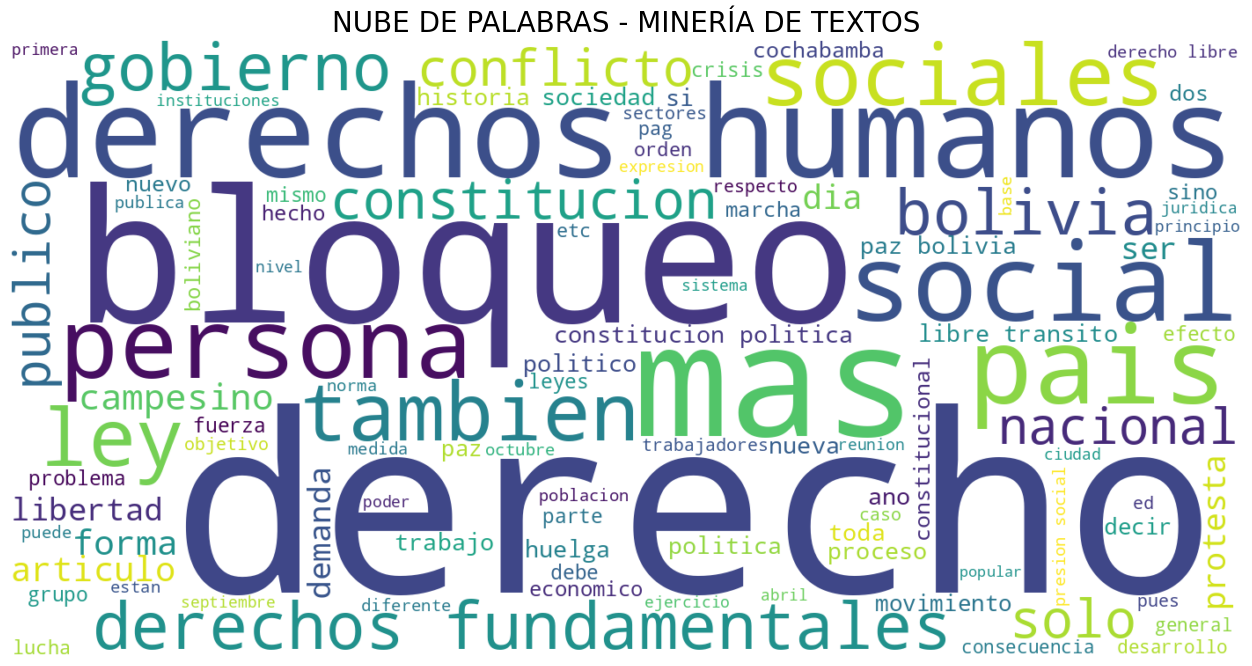

In [45]:

# =========================================================
# RESULTADO 16 - NUBE DE PALABRAS
# =========================================================

mostrar_titulo(
    "[16] NUBE DE PALABRAS"
)

generar_nube_palabras(
    documento_final
)


In [46]:

# =========================================================
# RESUMEN FINAL
# =========================================================

print("\n")
print("=" * 100)
print("RESUMEN DEL PROCESAMIENTO")
print("=" * 100)

print("""

ETAPAS EJECUTADAS:

✓ ETAPA 0 - Preparación de fuentes
✓ ETAPA 1 - Adquisición de fuentes
✓ ETAPA 2 - Limpieza del texto
✓ ETAPA 3 - Preparación para el análisis

PROCESOS REALIZADOS:

✓ Control de tamaño
✓ Extracción de texto PDF
✓ Verificación de codificación
✓ Detección de idioma
✓ Limpieza básica
✓ Eliminación de ruido
✓ Normalización textual
✓ Tokenización
✓ Eliminación de stopwords
✓ Implementación de stemming
✓ Implementación de lematización
✓ Construcción de matriz DTM
✓ Construcción de matriz TDM
✓ Frecuencia de términos
✓ Nube de palabras

RESULTADO FINAL:

El documento PDF fue transformado correctamente
en un corpus textual estructurado y preparado para:

• Minería de textos
• NLP
• Clasificación documental
• Clustering
• Análisis semántico
• Ciencia de datos
• Aprendizaje automático

""")

print("=" * 100)
print("PROCESAMIENTO FINALIZADO CORRECTAMENTE")
print("=" * 100)



RESUMEN DEL PROCESAMIENTO


ETAPAS EJECUTADAS:

✓ ETAPA 0 - Preparación de fuentes
✓ ETAPA 1 - Adquisición de fuentes
✓ ETAPA 2 - Limpieza del texto
✓ ETAPA 3 - Preparación para el análisis

PROCESOS REALIZADOS:

✓ Control de tamaño
✓ Extracción de texto PDF
✓ Verificación de codificación
✓ Detección de idioma
✓ Limpieza básica
✓ Eliminación de ruido
✓ Normalización textual
✓ Tokenización
✓ Eliminación de stopwords
✓ Implementación de stemming
✓ Implementación de lematización
✓ Construcción de matriz DTM
✓ Construcción de matriz TDM
✓ Frecuencia de términos
✓ Nube de palabras

RESULTADO FINAL:

El documento PDF fue transformado correctamente
en un corpus textual estructurado y preparado para:

• Minería de textos
• NLP
• Clasificación documental
• Clustering
• Análisis semántico
• Ciencia de datos
• Aprendizaje automático


PROCESAMIENTO FINALIZADO CORRECTAMENTE


In [47]:
# Para ver la cantidad de repeticiones por palabras (ordenadas de mayor a menor frecuencia)
from nltk import FreqDist
freq = FreqDist(tokens_sin_stopwords)
print(freq.most_common(20))
# print(freq.most_common()) # esto es para todo

[('derechos', 212), ('derecho', 189), ('sociales', 93), ('constitucion', 89), ('social', 88), ('bolivia', 83), ('mas', 80), ('bloqueo', 74), ('humanos', 67), ('paz', 59), ('fundamentales', 58), ('politica', 56), ('nacional', 55), ('pais', 54), ('tambien', 53), ('ley', 51), ('sociedad', 46), ('bloqueos', 45), ('solo', 42), ('gobierno', 42)]
